
# Patient readmission - Model Explainability 

<img src="https://github.com/databricks-demos/dbdemos-resources/blob/main/images/hls/patient-readmission/patient-risk-ds-flow-5.png?raw=true" width="700px" style="float: right; margin-left: 10px;" />

Being able to understand our model prediction and which condition or criteria the readmission risk is key to increase healthcare quality.

In this example, we'll explain our model for the entire cohort, but also provide explanation for a specific patient.

This information can be used to improve global care but also provide more context for a specific patient.

<!-- Collect usage data (view). Remove it to disable collection. View README for more details.  -->
<img width="1px" src="https://ppxrzfxige.execute-api.us-west-2.amazonaws.com/v1/analytics?category=lakehouse&org_id=2162748966026566&notebook=%2F04-Data-Science-ML%2F04.5-Explainability-patient-readmission&demo_name=lakehouse-hls-readmission&event=VIEW&path=%2F_dbdemos%2Flakehouse%2Flakehouse-hls-readmission%2F04-Data-Science-ML%2F04.5-Explainability-patient-readmission&version=1">

In [0]:
%pip install databricks-sdk==0.39.0 mlflow==2.19.0 shap==0.46.0
dbutils.library.restartPython()

  Using cached databricks_sdk-0.39.0-py3-none-any.whl.metadata (38 kB)
  Using cached mlflow-2.19.0-py3-none-any.whl.metadata (30 kB)
  Using cached mlflow_skinny-2.19.0-py3-none-any.whl.metadata (31 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached graphql_relay-3.2.0-py3-none-any.whl.metadata (12 kB)
Using cached databricks_sdk-0.39.0-py3-none-any.whl (622 kB)
Using cached mlflow-2.19.0-py3-none-any.whl (27.4 MB)
Using cached mlflow_skinny-2.19.0-py3-none-any.whl (5.9 MB)
Using cached docker-7.1.0-py3-none-any.whl (147 kB)
Using cached graphene-3.4.3-py2.py3-none-any.whl (114 kB)
Using cached graphql_relay-3.2.0-py3-none-any.whl (16 kB)
  Attempting uninstall: databricks-sdk
    Found existing installation: databricks-sdk 0.30.0
    Not uninstalling databricks-sdk at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-be68d4

In [0]:
%run ../_resources/00-setup $reset_all_data=false

USE CATALOG `main__build`
using catalog.database `main__build`.`dbdemos_hls_readmission`


data already existing. Run with reset_all_data=true to force a data cleanup for your local demo.


In [0]:
#For this demo, reuse our dataset to test the batch inferences
dataset_to_explain = spark.table('training_dataset')
dataset_to_explain.display()

BIRTHDATE,DEATHDATE,PREFIX,SUFFIX,MAIDEN,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,MARITAL_D,MARITAL_M,MARITAL_S,MARITAL_W,RACE_asian,RACE_black,RACE_hawaiian,RACE_native,RACE_other,RACE_white,ETHNICITY_hispanic,ETHNICITY_nonhispanic,GENDER_F,GENDER_M,patient_id,START,STOP,30_DAY_READMISSION,ENCOUNTER_ID,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,enc_length,ENCOUNTERCLASS_ambulatory,ENCOUNTERCLASS_emergency,ENCOUNTERCLASS_hospice,ENCOUNTERCLASS_inpatient,ENCOUNTERCLASS_outpatient,ENCOUNTERCLASS_wellness,age_at_encounter
1960-10-12,2020-11-06,Mr.,null,null,Fall River,Massachusetts,Bristol County,25005.0,2747,41.750834597751016,-71.0452961077422,162261.25,895558.02,30440,0,0,1,0,0,0,0,0,0,1,0,1,0,1,5646f81d-85f2-c2d2-aa1d-3c30a0413148,2002-04-24T03:33:13Z,2002-04-24T04:21:41Z,0,0003e61d-9662-5111-f6ad-48646551f28c,85.55,802.11,0.0,2908,0,0,0,0,1,0,41.530458590006845
1949-11-14,null,Ms.,null,null,Bolton,Massachusetts,Worcester County,null,0,42.42686500765992,-71.61398510432554,259195.31,1819638.61,817966,0,0,1,0,0,1,0,0,0,0,0,1,1,0,ec3eb7ce-a707-49d3-c67b-758d354b1927,1949-12-19T02:05:57Z,1949-12-19T02:20:57Z,0,0005e160-77df-b17d-7d70-8d34abca9441,136.8,493.85,0.0,900,0,0,0,0,0,1,0.09582477754962354
1920-08-21,null,Mr.,null,null,Cochituate,Massachusetts,Middlesex County,null,0,42.28831634372727,-71.30992405399289,123160.4,1023238.6,858253,0,1,0,0,0,0,0,0,0,1,0,1,0,1,6d241af0-a1b5-6223-1843-b44e39b85659,2022-10-10T01:50:33Z,2022-10-10T02:05:33Z,1,0006bcbf-7d8c-2dcf-9c01-31cba06578bd,85.55,234.71,187.76,900,1,0,0,0,0,0,102.13552361396304
1960-03-31,null,Mr.,null,null,Gloucester,Massachusetts,Essex County,25009.0,1930,42.60004264570648,-70.66116465835674,27815.18,944263.9,19864,0,1,0,0,0,0,0,0,0,1,0,1,0,1,e1810300-6248-ae6c-d847-4d3a09fdfddb,2019-11-14T16:23:42Z,2019-11-14T17:16:28Z,1,0018bc8d-1712-9426-4839-95addc260c48,85.55,8251.87,8216.87,3166,0,0,0,0,1,0,59.62217659137577
1915-01-17,null,Mr.,null,null,Randolph,Massachusetts,Norfolk County,25021.0,2368,42.15366529705856,-71.04899600973981,221553.61,758519.43,45887,0,1,0,0,0,0,0,0,0,1,0,1,0,1,a8992104-8997-4c74-3480-3b66fd23df64,2017-08-27T14:50:54Z,2017-08-27T15:37:43Z,1,001b4d2a-a50b-c76d-d8cc-defa5a6b78e8,85.55,1179.74,943.78,2809,0,0,0,0,1,0,102.60917180013689
1960-10-12,2020-11-06,Mr.,null,null,Fall River,Massachusetts,Bristol County,25005.0,2747,41.750834597751016,-71.0452961077422,162261.25,895558.02,30440,0,0,1,0,0,0,0,0,0,1,0,1,0,1,5646f81d-85f2-c2d2-aa1d-3c30a0413148,1964-03-18T03:33:13Z,1964-03-18T03:48:13Z,0,0025e9ef-e36b-ebbe-4b19-72aa70f9a5f6,136.8,714.45,0.0,900,0,0,0,0,0,1,3.430527036276523
1959-07-01,null,Mr.,null,null,Newburyport,Massachusetts,Essex County,25009.0,1950,42.77880086615183,-70.86912980298715,95258.37,47651.28,126121,0,1,0,0,0,0,0,0,0,1,0,1,0,1,bb559f9e-c1ca-8dae-b3d5-12d95505fb98,1977-08-24T11:58:21Z,1977-08-24T12:42:44Z,0,002ab918-4e72-3216-cff6-893b003b978b,136.8,704.2,0.0,2663,0,0,0,0,0,1,18.1492128678987
1967-10-01,null,Ms.,null,null,Chelsea,Massachusetts,Suffolk County,25025.0,2151,42.4199237058549,-71.02552900372218,29100.6,1899452.29,18605,0,0,1,0,0,0,0,0,0,1,1,0,1,0,4c341ab3-7ecd-3ee6-ab0f-3fb78214d75f,2021-06-07T08:05:41Z,2021-06-07T09:17:24Z,0,002fce7f-eb35-996c-322c-7b587d8cfe2b,85.55,516.95,466.95,4303,1,0,0,0,0,0,53.68377823408624
1942-02-15,null,Mr.,null,null,Hopedale,Massachusetts,Worcester County,25027.0,1747,42.07755232349039,-71.58019896186094,111381.26,67109.96,830656,1,0,0,0,0,0,0,0,0,1,0,1,0,1,f86f92bf-9a5c-2c4e-906d-fe231585d560,2002-11-24T11:35:56Z,2002-11-24T12:23:38Z,0,0034de1c-5e1a-080a-81d1-599aa4443606,136.8,853.36,0.0,2862,0,0,0,0,0,1,60.772073921971256
1961-01-15,null,Mrs.,null,Nikolaus26,Pocasset,Massachusetts,Barnstable County,25001.0,2559,41.718558248476434,-70.57950414071792,595537.14,1067186.94,59555,1,0,0,0,0,0,0,0,0,1,0,1,1,0,377d69fa-d5e4-085a-cbda-6fabb1fb536e,1962-03-18T13:40:35Z,1962-03-18T13:55:35Z,0,00391881-6f97-9c35-d1d7-fe52b40e78f7,85.55,85.55,0.0,900,0,

## Load Model from the registry

In [0]:
import mlflow
#Enable Unity Catalog with mlflow registry
mlflow.set_registry_uri('databricks-uc')
client = mlflow.tracking.MlflowClient()

model = mlflow.pyfunc.load_model(model_uri=f"models:/{catalog}.{db}.dbdemos_hls_patient_readmission@prod")
features = model.metadata.get_input_schema().input_names()

2025/11/03 22:43:13 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.19.0, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


## Feature importance using Shapley values


SHAP is a game-theoretic approach to explain machine learning models, providing a summary plot of the relationship between features and model output. Features are ranked in descending order of importance, and impact/color describe the correlation between the feature and the target variable.
- Generating SHAP feature importance is a very memory intensive operation.<br />
- To reduce the computational overhead of each trial, a single example is sampled from the cohort to explain.<br />
  For more thorough results, increase the sample size of explanations, or provide your own examples to explain.

For more information on how to read Shapley values, see the [SHAP documentation](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html).

In [0]:
import shap
mlflow.autolog(disable=True)
mlflow.sklearn.autolog(disable=True)

df = dataset_to_explain.sample(fraction=0.1).toPandas()

train_sample = df[features].sample(n=np.minimum(100, df.shape[0]), random_state=42)

# Use Kernel SHAP to explain feature importance on the sampled rows from the validation set.
predict = lambda x: model.predict(pd.DataFrame(x, columns=features).astype(train_sample.dtypes.to_dict()))

explainer = shap.KernelExplainer(predict, train_sample, link="identity")
shap_values = explainer.shap_values(train_sample, l1_reg=False, nsamples=100)

[LightGBM] [Warning] lambda_l2 is set=4.314644989541198, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.314644989541198
[LightGBM] [Warning] lambda_l1 is set=0.11039283799769356, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11039283799769356


  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l2 is set=4.314644989541198, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.314644989541198
[LightGBM] [Warning] lambda_l1 is set=0.11039283799769356, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11039283799769356
[LightGBM] [Warning] lambda_l2 is set=4.314644989541198, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.314644989541198
[LightGBM] [Warning] lambda_l1 is set=0.11039283799769356, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11039283799769356
[LightGBM] [Warning] lambda_l2 is set=4.314644989541198, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.314644989541198
[LightGBM] [Warning] lambda_l1 is set=0.11039283799769356, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11039283799769356
[LightGBM] [Warning] lambda_l2 is set=4.314644989541198, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.314644989541198
[LightGBM] [Warning] lambda_l1 is set=0.11039283799769356, reg_alph

In [0]:
import plotly.express as px
mean_abs_shap = np.absolute(shap_values).mean(axis=0).tolist()
df = pd.DataFrame(list(zip(mean_abs_shap,features)), columns=['SHAP_value', 'feature'])
px.bar(df.sort_values('SHAP_value', ascending=False).head(10), x='feature', y='SHAP_value')

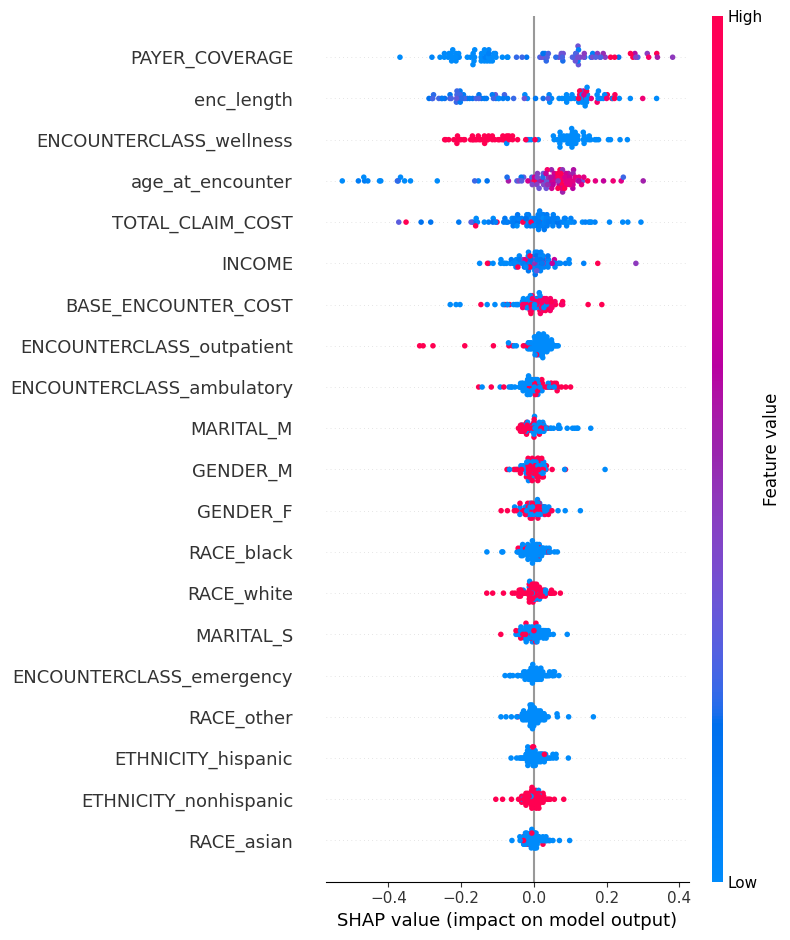

In [0]:
shap.summary_plot(shap_values, train_sample)

Shapely values can also help for the analysis of local, instance-wise effects. 

We can also easily explain which feature impacted the decision for a given user. This can helps agent to understand the model an personalized health care further.

In [0]:
#We'll need to add shap bundle js to display nice graph
with open(shap.__file__[:shap.__file__.rfind('/')]+"/plots/resources/bundle.js", 'r') as file:
   shap_bundle_js = '<script type="text/javascript">'+file.read()+'</script>'

html = shap.force_plot(explainer.expected_value, shap_values[0,:], train_sample.iloc[0,:])
displayHTML(shap_bundle_js + html.html())

If we take many individual explanations such as the one shown above, rotate them 90 degrees, and then stack them horizontally, we can see explanations for an entire dataset:

In [0]:
plot_html = shap.force_plot(explainer.expected_value, shap_values, train_sample)
displayHTML(shap_bundle_js + plot_html.html())

To understand how a single feature effects the output of the model we can plot the SHAP value of that feature vs. the value of the feature for all the examples in a dataset. 

Since SHAP values represent a feature's responsibility for a change in the model output, the plot below represents the change in the readmission risk as TOTAL_CLAIM_COST changes. 

To help reveal these interactions dependence_plot can selects another feature for coloring, in this case TOTAL_CLAIM_COST, showing in this case no direct relation.

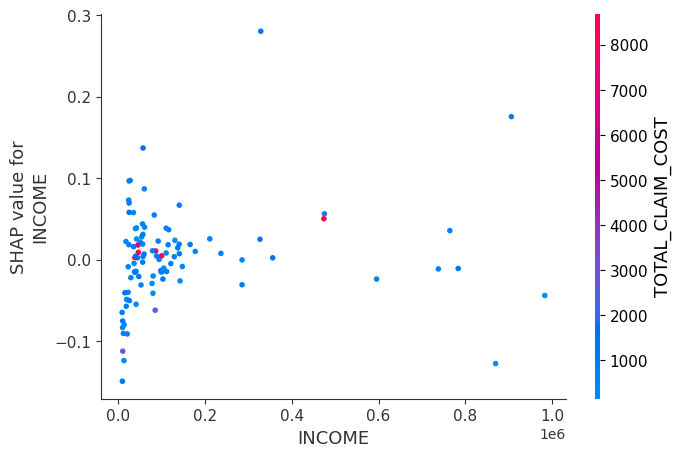

In [0]:
shap.dependence_plot("INCOME", shap_values, train_sample[features], interaction_index="TOTAL_CLAIM_COST")

#### Computing SHAP values on the entier dataset:
These graph are great to understand the model against a subset of data. If we want to to further analyze based on the shap values on millions on rows, we can use spark to compute the shap values.

We can use spark 3 `mapInPandas` function, or create a `@pandas_udf`:


In [0]:
import pandas as pd
def compute_shap_values(iterator):
  for X in iterator:
    yield pd.DataFrame(explainer.shap_values(X, check_additivity=False))

df = dataset_to_explain.mapInPandas(compute_shap_values, schema=", ".join([x+"_shap_value float" for x in features]))

# Skip as this can take some time to run
#display(df)


## Conclusion: the power of the Lakehouse

In this demo, we've seen an end 2 end flow with the Lakehouse:


- Data ingestion made simple with Spark Declarative Pipelines
- Leveraging Databricks notebooks and SQL warehouse to create, anaylize and share our dashboards 
- Model Training with AutoML for citizen Data Scientist
- Ability to tune our model for better results, improving our patient journey quality
- Ultimately, the ability to deploy and make explainable ML predictions, made possible with the full Lakehouse capabilities.

[Go back to the introduction]($../00-patient-readmission-introduction) or discover how to use Databricks Workflow to orchestrate this tasks: [05-Workflow-Orchestration-patient-readmission]($../05-Workflow-Orchestration/05-Workflow-Orchestration-patient-readmission)